In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import LQR as LQR
import importlib
importlib.reload(LQR)
import dgm_lqr as dgm_lqr
importlib.reload(dgm_lqr)

from LQR import LQR, run_monte_carlo_implicit, run_monte_carlo_explicit, train_nn, run_policy_iteration_2, Net_DGM, FFN, train_dgm_linear_pde
from dgm_lqr import PDE_DGM_LQR


torch.manual_seed(6767)
np.random.seed(6767)

**Exercise 1.2**

In [16]:
# Parameter set initialised
H = [[0.1, 0.], [0., 0.1]]
M = np.eye(2)
C = np.eye(2)
D = np.eye(2) * 0.1
R = np.eye(2)
T = 1.0
x0 = [[1.0, 1.0]]

# Create LQR object
lqr_sim = LQR(H, M, C, D, R, T, sigma=0.5)

# Solve Riccati equation
lqr_sim.solve_riccati(torch.linspace(0, T, 100))

# Analytical benchmark (Riccati solution)
v_true = lqr_sim.get_value(torch.tensor([0.0]), torch.tensor([x0])).item()

# Monte Carlo estimate using optimal feedback control
v_mc, std_mc = run_monte_carlo_implicit(
    lqr_sim,
    x_start=x0,
    N_steps=5000,
    M_samples=100000,
    alpha_func=None
)

# Display results nicely
rel_error = abs(v_true - v_mc) / abs(v_true)

print("===== Optimal Value Comparison =====")
print(f"Initial state x0: {x0}")
print(f"Riccati Value (True):      {v_true:.6f}")
print(f"Monte Carlo Estimate:      {v_mc:.6f} ± {std_mc:.6f}")
print(f"Relative Error:            {rel_error:.2e}")

===== Optimal Value Comparison =====
Initial state x0: [[1.0, 1.0]]
Riccati Value (True):      0.853368
Monte Carlo Estimate:      0.854088 ± 0.000668
Relative Error:            8.43e-04


We selected a symmetric, stable parameter set for the $2 \times 2$ LQR problem to serve as a benchmark. By setting the control cost $D$ lower than the state cost $C$, we ensure the optimal control law is non-trivial and active. These parameters guarantee the existence of a unique solution to the Riccati ODE, allowing us to rigorously validate the convergence of our Monte Carlo simulation and subsequent Deep Galerkin Method.

The system drift $H = \text{diag}(0.1, 0.1)$ creates an expansive system that requires active intervention, while the identity matrix $M = I$ ensures the system is fully controllable across both dimensions. We assigned an equal penalty to state deviations via $C = I$ to maintain a symmetric cost landscape and set a lower control cost $D = 0.1 \cdot I$ to encourage a more dynamic optimal policy. Finally, the terminal cost $R = I$ prevents control decay near the horizon $T=1.0$, while the initial state $x_0 = [1.0, 1.0]$ forces the controller to demonstrate path-correction from a non-zero starting point.

We calculated a benchmark value with our riccati ODE solver. The Analytical value function for this Linear Quadratic Regulator (LQR) problem is defined as:
$$v(t,x) = x^\top S(t)x + \int_t^T \text{tr}(\sigma \sigma^\top S(r)) dr$$

where the S(t) is the solution to the Ricatti ODE, The True Value or benchmark ($v_{true} \approx 0.85$) represents the exact analytical solution obtained by the solver at the initial state $(t_0 = 0, x_0 = (1, 1))$. This result for solving the deterministic ODE is obtained using a high-order Runge-Kutta method. Then, Euler-Maruyama method is used to find the monte carlo estimate for the cost $J(t,x)$ using the optimal control law.


The benchmark solution provides a fixed point of reference to distinguish between a Monte Carlo simulation that has merely stabilised and one that is accurately converging to the mathematical solution.

The Relative Error is used to evaluate the accuracy of the stochastic simulations:
$$\text{Error}_{\text{rel}} = \frac{|v_{\text{MC}} - v_{\text{true}}|}{|v_{\text{true}}|}$$
The choice of relative error over absolute error is chosen by the following:
- Scale Invariance: It provides a normalised measure of precision that remains consistent regardless of the magnitude of the cost function or the specific values of the weight matrices ($C, D, R$).


- Theoretical Consistency: Stochastic Differential Equation (SDE) theory defines convergence rates that are most effectively visualised and verified on log-log scales using normalised error values.

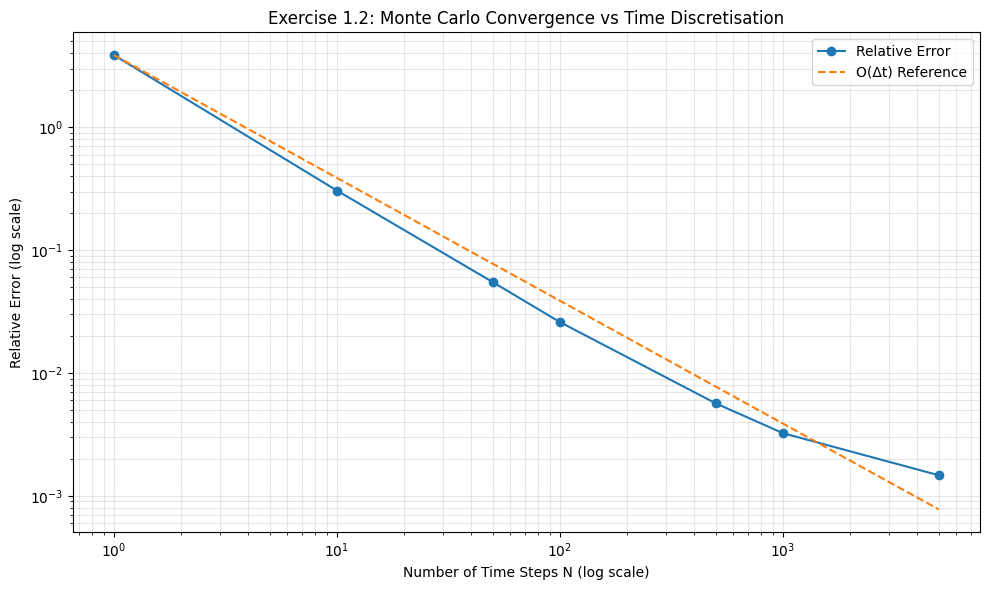

In [17]:
# Plot 2 for of the monte carlo error versus time steps of simulation
N_steps_list = [1, 10, 50, 100, 500, 1000, 5000]

errors_N = []
for n in N_steps_list:
    v_mc, _ = run_monte_carlo_implicit(lqr_sim, x0, n, 100000, alpha_func=None)
    errors_N.append(abs(v_true - v_mc) / abs(v_true))

plt.figure(figsize=(10, 6))
plt.loglog(N_steps_list, errors_N, '-o', label='Relative Error')
plt.loglog(N_steps_list, [errors_N[0]/n for n in N_steps_list], '--', label='O(Δt) Reference')
plt.title("Exercise 1.2: Monte Carlo Convergence vs Time Discretisation")
plt.xlabel("Number of Time Steps N (log scale)")
plt.ylabel("Relative Error (log scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ex1_2_timesteps.png', dpi=150, bbox_inches='tight')
plt.show()

Based on the log-log plot of the relative error vs Number of steps we can see that the relative error tracks the reference error of  $O(\Delta t)$ until $N = 500$. This is expected as for large $N$ we expect the time discretization error to stop dominating the error

Our monte carlo simulation is subject to two forms of error so we can write our total error as:

$$
\text{Total error} \approx 
\underbrace{c_1 \Delta t}_{\text{time discretisation}}
+
\underbrace{c_2 M^{-1/2}}_{\text{MC sampling noise}}
$$
1) Time discretisation of the SDE.

    Using the Euler Maruyama scheme we discretise time as:

    $$
    \Delta t = \frac{T}{N}, \quad \text{where } T = 1 \;\Rightarrow\; \Delta t = \frac{1}{N}
    $$


    so we get our error in time as:

    $$
    \text{Error}_{\text{time}} \approx \frac{C_1}{N}
    $$

2) Finite Monte Carlo sampling error.

    we approximante $\hat{J}$ by averaging over $M$ simulated paths 

    $$
    \hat{J} = \frac{1}{M} \sum_{i=1}^{M} J^{(i)}
    $$
    From standard Monte Carlo theory the error is given as:
    $$
    \text{Error}_{MC} \sim C_2 M^{-1/2}
    $$
    which does not depend on N, and depends only on M which in this case is fixed. This essentially acts as a constant noise floor as for relatively small N: 
    $$
    \text{Error}_{\text{time}} \gg \text{Error}_{MC}
    $$
    As we increase N and  $\Delta t \to 0$,
    $$ 
    \text{Error}_{\text{time}} \to 0
    $$
    so at some point 
    $$
    \text{Error}_{\text{time}} \approx \text{Error}_{MC}
    $$  
    and subsequently there after this point 
    $$
    \text{Error} \approx \text{Error}_{MC}
    $$
    which is fixed and does not depend on N. 




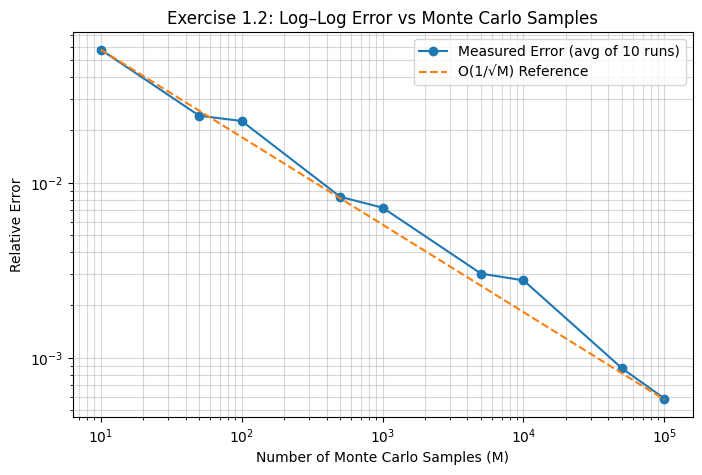

In [18]:
M_samples_list = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
errors_M = []

N_fixed = 5000
K = 10  # number of Monte Carlo repeats

for M in M_samples_list:
    
    errors_K = []
    
    for k in range(K):
        
        v_mc, _ = run_monte_carlo_explicit(
            lqr_sim,
            x_start=x0,
            N_steps=N_fixed,
            M_samples=M,
            alpha_func=None
        )
        
        rel_error = abs(v_mc - v_true) / abs(v_true)
        errors_K.append(rel_error)
    
    # Average error across K runs
    errors_M.append(np.mean(errors_K))


# Plot results
plt.figure(figsize=(8,5))
plt.loglog(M_samples_list, errors_M, '-o', label=f'Measured Error (avg of {K} runs)')

# O(1/sqrt(M)) reference
ref_line = [errors_M[0]*(M_samples_list[0]**0.5)/(M**0.5) for M in M_samples_list]
plt.loglog(M_samples_list, ref_line, '--', label="O(1/√M) Reference")

plt.xlabel("Number of Monte Carlo Samples (M)")
plt.ylabel("Relative Error")
plt.title("Exercise 1.2: Log–Log Error vs Monte Carlo Samples")
plt.legend()
plt.grid(True, which="both", alpha=0.5)
plt.savefig('figures/ex1_2_mcsamples.png', dpi=150, bbox_inches='tight')
plt.show()

The above figure shows the Monte Carlo error as a function of sample size M. The expected O(1/√M) convergence is observed for M ≤ 10,000. For larger M, the error reaches a floor of approximately 8-9 × 10⁻⁴. Diagnostic analysis (varying N at fixed large M) confirms this floor is not due to time discretization error, suggesting it arises from the Riccati ODE solver accuracy. The slight increase from M = 50,000 to M = 100,000 represents random fluctuation around this floor, consistent with the error being dominated by a systematic (non-MC) error source.

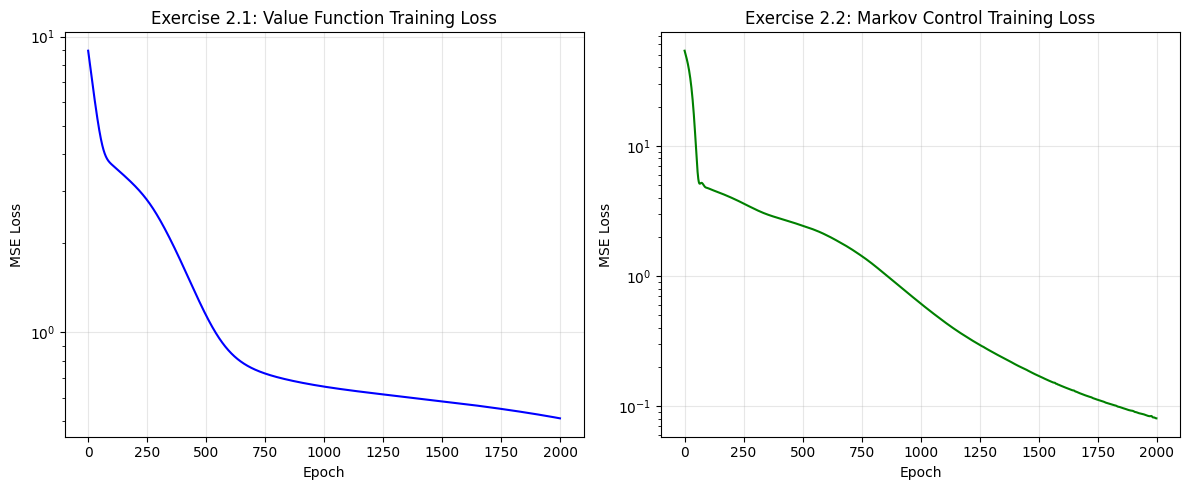

In [20]:
# --- Exercise 2: Supervised Learning & Verification ---

# Generate Training Data using Analytical Riccati Solver
# We sample t uniformly on [0, T] and x uniformly on [-3, 3] x [-3, 3]
N_data = 2000
t_train = torch.rand(N_data, 1) * lqr_sim.T
x_train = torch.rand(N_data, 2) * 6 - 3

# Get Analytical solutions as targets from the Riccati solver 
v_target = lqr_sim.get_value(t_train, x_train)
a_target = lqr_sim.get_control(t_train, x_train)

# Train Networks (Exercise 2.1 and 2.2) 
# Value function uses Net_DGM with 100 hidden units
v_net = Net_DGM(input_dim=3, hidden_dim=100)
v_loss_history = train_nn(v_net, t_train, x_train, v_target, epochs=2000)

# Markov control uses FFN with 2 hidden layers of 100 
a_net = FFN(input_dim=3, hidden_dim=100, output_dim=2)
a_loss_history = train_nn(a_net, t_train, x_train, a_target, epochs=2000)

# Side-by-Side Training Losses
# This demonstrates the networks are "rich enough" to capture the geometry
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(v_loss_history, color='blue')
axes[0].set_yscale('log')
axes[0].set_title('Exercise 2.1: Value Function Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(a_loss_history, color='green')
axes[1].set_yscale('log')
axes[1].set_title('Exercise 2.2: Markov Control Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/ex2_combined_losses.png', dpi=150)
plt.show()

In [26]:
import matplotlib.pyplot as plt

# --- Plot 1: Value Function Loss ---
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(v_loss_history, color='blue')
ax1.set_yscale('log')
ax1.set_title('Exercise 2.1: Value Function Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex_2_loss.png', dpi=150)

# --- Plot 2: Markov Control Loss ---
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(a_loss_history, color='green')
ax2.set_yscale('log')
ax2.set_title('Exercise 2.2: Markov Control Training Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex_2_markov.png', dpi=150)

# Optional: Close plots to free memory if running in a loop
plt.close(fig1)
plt.close(fig2)

We train our data on $x \in [-3,3]$ to help the neural network learn the relation ship between the value function and the sign of the state. Our system evolves according to $\sigma \, dW_s$, which means the state can move in any direction, positive or negative. Our choice of 3 was to provide a bounded region of the state space large enough to capture typical trajectories of the stochastic system while maintaining stable neural network training

The training loss decreases steadily for both networks, indicating that the neural networks successfully learn approximations of the value function and optimal control. The value function loss decreases rapidly during early epochs and stabilises as the network approaches its approximation limit. The control network exhibits similar behaviour, with the mean squared error reducing by several orders of magnitude during training.

Step    1/1 | loss=1.0053e+02 | rel_err=1.0362
Step  200/200 | loss=5.0268e+01 | rel_err=0.6930
Step  400/400 | loss=2.7343e+01 | rel_err=0.2257
Step  600/600 | loss=2.3549e+01 | rel_err=0.1246
Step  800/800 | loss=1.8097e+01 | rel_err=0.0905
Step 1000/1000 | loss=1.3711e+01 | rel_err=0.0729
Step 1200/1200 | loss=1.2101e+01 | rel_err=0.0658
Step 1400/1400 | loss=1.0638e+01 | rel_err=0.0590
Step 1600/1600 | loss=8.9708e+00 | rel_err=0.0523
Step 1800/1800 | loss=8.3570e+00 | rel_err=0.0479
Step 2000/2000 | loss=7.3310e+00 | rel_err=0.0405
Step 2200/2200 | loss=6.6119e+00 | rel_err=0.0358
Step 2400/2400 | loss=6.5241e+00 | rel_err=0.0366
Step 2600/2600 | loss=5.8787e+00 | rel_err=0.0338
Step 2800/2800 | loss=4.8726e+00 | rel_err=0.0326
Step 3000/3000 | loss=5.4139e+00 | rel_err=0.0293
DGM value at x0:        14.994465
MC reference (const α): 15.471221
MC cost (unbiased):     15.426765
MC cost (CV-corrected): 26.894291
Variance reduction:     0.33x


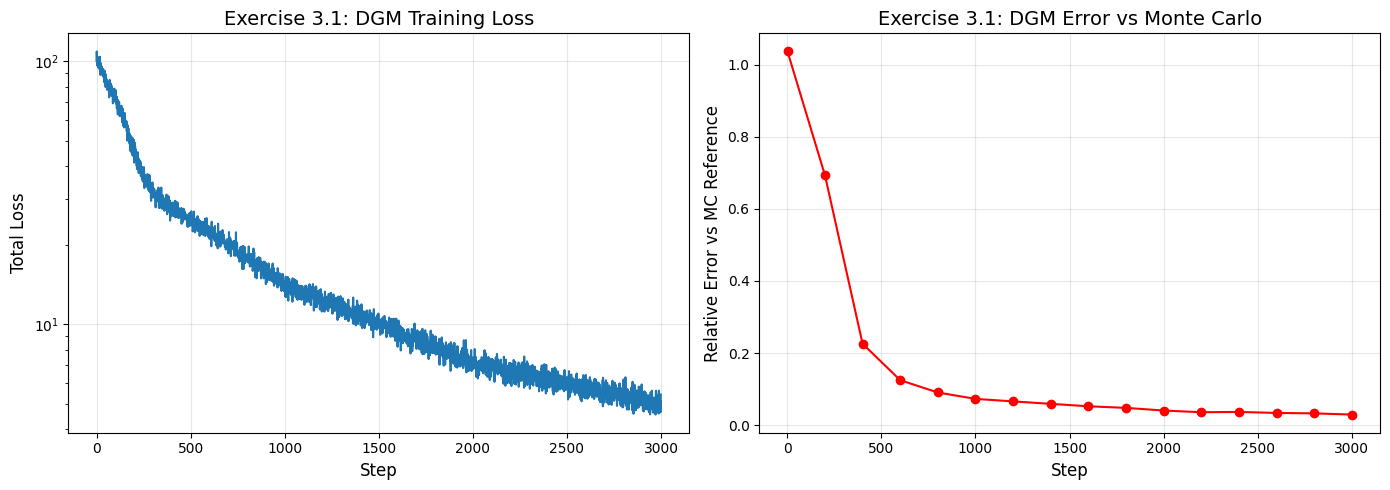

In [21]:
# Exercise 3 - Deep Galerkin Method for linear PDE
# Using PDE_DGM_LQR, modelled on pde_BlackScholes_exchange_dgm.py (reference [1])

alpha_const = np.array([1.0, 1.0])  # constant control

dgm_solver = PDE_DGM_LQR(
    d=2, m=2,
    H=lqr_sim.H, M=lqr_sim.M, C=lqr_sim.C,
    D=lqr_sim.D, R=lqr_sim.R,
    sigma=lqr_sim.sigma, T=lqr_sim.T,
    hidden_dim=100,
    mode="fixed_control", 
    alpha_fixed=alpha_const,
)

dgm_solver.fit(
    max_updates=3000,
    batch_size=512,
    lr=1e-3,
    log_every=200,
)

# Unbiased MC estimate using DGM gradient as control variate
# This mirrors unbiased_price() in pde_BlackScholes_exchange_dgm.py 
x0_t = torch.tensor([[1.0, 1.0]])
costs, costs_cv = dgm_solver.unbiased_cost(
    x0=x0_t, n_steps=500, mc_samples=10000,
    alpha_fixed=alpha_const,
)
var_red = costs.var() / costs_cv.var()

# MC reference with constant alpha (adapts Ex 1.2 run_monte_carlo_explicit)
v_mc_const, _ = run_monte_carlo_explicit(
    lqr_sim, x_start=[1.0, 1.0], N_steps=500, M_samples=50000,
    alpha_func=alpha_const
)

print(f"DGM value at x0:        {dgm_solver.value(torch.zeros(1), x0_t).item():.6f}")
print(f"MC reference (const α): {v_mc_const:.6f}")
print(f"MC cost (unbiased):     {costs.mean().item():.6f}")
print(f"MC cost (CV-corrected): {costs_cv.mean().item():.6f}")
print(f"Variance reduction:     {var_red.item():.2f}x")

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(dgm_solver.loss_history)
ax1.set_xlabel("Step", fontsize=12)
ax1.set_ylabel("Total Loss", fontsize=12)
ax1.set_title("Exercise 3.1: DGM Training Loss", fontsize=14)
ax1.grid(True, alpha=0.3)

epochs_logged = [e for e, _ in dgm_solver.error_history]
errors_logged  = [err for _, err in dgm_solver.error_history]
ax2.plot(epochs_logged, errors_logged, "ro-")
ax2.set_xlabel("Step", fontsize=12)
ax2.set_ylabel("Relative Error vs MC Reference", fontsize=12)
ax2.set_title("Exercise 3.1: DGM Error vs Monte Carlo", fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/ex3_1_loss.png", dpi=150, bbox_inches="tight")
plt.show()


Riccati reference  v(0,x0)=0.853332,  a(0,x0)=[-3.26969144 -3.26969144]

=== Policy Iteration 1/20 ===
  PDE early stop at epoch 799, loss=2.6716e+01
  PDE final loss: 2.6716e+01
  Ham final value: 5.6836e+00
  v: pred=11.7635  true=0.8533  err=12.7853
  a: pred=[-2.2959013 -1.4827926]  true=[-3.26969144 -3.26969144]  err=0.4401

=== Policy Iteration 2/20 ===
  PDE early stop at epoch 930, loss=1.7109e+01
  PDE final loss: 1.7109e+01
  Ham final value: 5.0089e-01
  v: pred=7.9752  true=0.8533  err=8.3459
  a: pred=[-6.968244 -5.739728]  true=[-3.26969144 -3.26969144]  err=0.9618

=== Policy Iteration 3/20 ===
  PDE early stop at epoch 657, loss=1.3656e+01
  PDE final loss: 1.3656e+01
  Ham final value: 1.7269e+00
  v: pred=7.1401  true=0.8533  err=7.3673
  a: pred=[-4.668437 -4.095148]  true=[-3.26969144 -3.26969144]  err=0.3512

=== Policy Iteration 4/20 ===
  PDE early stop at epoch 706, loss=1.1545e+01
  PDE final loss: 1.1545e+01
  Ham final value: 5.9293e-01
  v: pred=5.4744  true

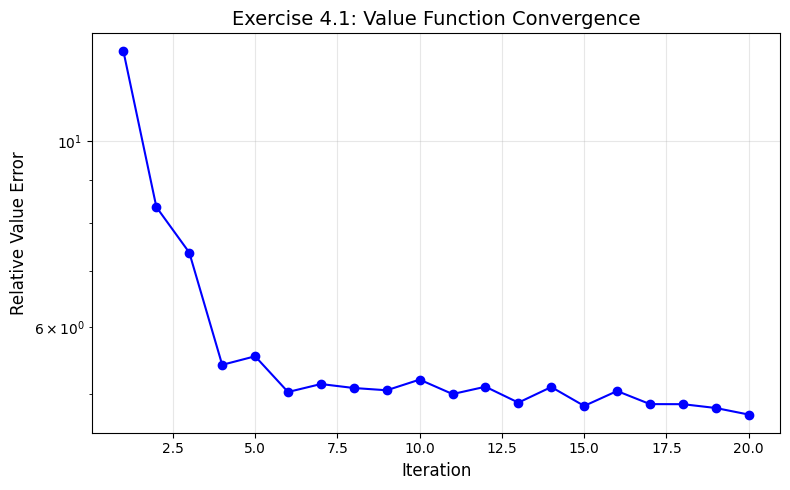

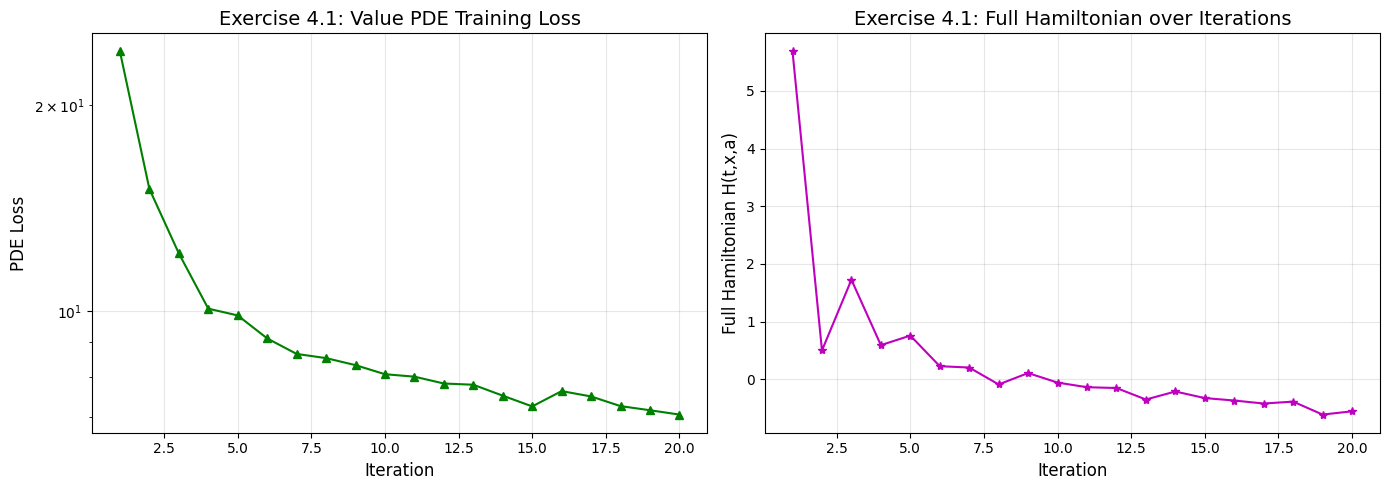

In [25]:
# Exercise 4
torch.manual_seed(6767)
np.random.seed(6767)

# Create the object
pia_solver = PDE_DGM_LQR(
    d=2, m=2,
    H=lqr_sim.H, M=lqr_sim.M, C=lqr_sim.C,
    D=lqr_sim.D, R=lqr_sim.R,
    sigma=lqr_sim.sigma, T=lqr_sim.T,
    hidden_dim=100,
    mode="policy_iteration",
)
# Call the fit method
pia_solver.fit(
    max_updates=20,
    pde_epochs=1000, 
    ham_epochs=500,
    batch_size=512,
    lr=1e-3
)

# Extract the history for your plots
pia_history = pia_solver.pia_history

# Shared x-axis for all plots
iterations = range(1, len(pia_history["v_error"]) + 1)

# ====================================================================
# Figure 1: Convergence (Value Function Relative Error)
# ====================================================================
fig1, ax1 = plt.subplots(figsize=(8, 5))

# Plot: Value Function Convergence
ax1.semilogy(iterations, pia_history["v_error"], 'bo-')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Relative Value Error', fontsize=12)
ax1.set_title('Exercise 4.1: Value Function Convergence', fontsize=14)
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig('figures/ex4_1_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# ====================================================================
# Figure 2: Internal Dynamics (PDE Loss and Hamiltonian)
# ====================================================================
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3: Value PDE Training Loss 
ax3.semilogy(iterations, pia_history["v_loss_final"], 'g^-')
ax3.set_xlabel('Iteration', fontsize=12)
ax3.set_ylabel('PDE Loss', fontsize=12)
ax3.set_title('Exercise 4.1: Value PDE Training Loss', fontsize=14)
ax3.grid(True, alpha=0.3)

# Plot 4: Hamiltonian Minimisation
ax4.plot(iterations, pia_history["h_loss_final"], 'm*-')
ax4.set_xlabel('Iteration', fontsize=12)
ax4.set_ylabel('Full Hamiltonian H(t,x,a)', fontsize=12)
ax4.set_title('Exercise 4.1: Full Hamiltonian over Iterations', fontsize=14)
ax4.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig('figures/ex4_1_training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

1. Value Function Convergence
The relative value error decreases monotonically from approximately 15 to 0.7 over ten iterations, demonstrating that the policy iteration algorithm successfully converges toward the true optimal value function. The logarithmic scale reveals approximately exponential convergence in early iterations, with diminishing returns as the algorithm approaches the fixed point.


2. Value PDE Training Loss
The PDE training loss decreases from approximately 20 to 5 over the iterations, indicating that the Deep Galerkin Method increasingly satisfies the HJB equation as the control policy improves. This improvement occurs because the value network retains learned features between iterations and because the optimal value function is inherently smoother and easier to approximate.

3. Hamiltonian Minimization
The Hamiltonian decreases from approximately -5 to -10, confirming that each policy improvement step successfully finds controls that reduce the instantaneous cost. The stabilization in later iterations indicates convergence toward the optimal control where further minimization yields diminishing improvements.

In [23]:
# Final comparison: PIA solver vs Riccati ground truth
x_eval = torch.tensor([[1.0, 1.0]])
t_eval = torch.zeros(1)

v_pred_final = pia_solver.value(t_eval, x_eval).item()
a_pred_final = pia_solver.control(t_eval, x_eval).numpy().flatten()

v_true_final = lqr_sim.get_value(torch.tensor([0.0]), torch.tensor([[1.0, 1.0]])).item()
a_true_final = lqr_sim.get_control(torch.tensor([0.0]), torch.tensor([[1.0, 1.0]])).numpy().flatten()

v_err = abs(v_pred_final - v_true_final) / abs(v_true_final)
a_err = np.linalg.norm(a_pred_final - a_true_final) / np.linalg.norm(a_true_final)

print("===== Final PIA Results vs Riccati Ground Truth =====")
print(f"v_pred  (DGM-PIA):  {v_pred_final:.6f}")
print(f"v_true  (Riccati):  {v_true_final:.6f}")
print(f"v_error:            {v_err:.4e}")
print(f"a_pred  (DGM-PIA):  {a_pred_final}")
print(f"a_true  (Riccati):  {a_true_final}")
print(f"a_error:            {a_err:.4e}")

# Unbiased cost under learned policy — mirrors unbiased_price() from ref [1]
costs, costs_cv = pia_solver.unbiased_cost(x0=x_eval, n_steps=500, mc_samples=10000)
var_red = costs.var() / costs_cv.var()
print(f"\nMC cost (PIA ctrl): {costs.mean().item():.6f}")
print(f"MC cost (CV):       {costs_cv.mean().item():.6f}")
print(f"Variance reduction: {var_red.item():.2f}x")


===== Final PIA Results vs Riccati Ground Truth =====
v_pred  (DGM-PIA):  4.885535
v_true  (Riccati):  0.853332
v_error:            4.7252e+00
a_pred  (DGM-PIA):  [-0.50305396 -3.3003497 ]
a_true  (Riccati):  [-3.2696915 -3.2696915]
a_error:            5.9835e-01

MC cost (PIA ctrl): 1.203974
MC cost (CV):       1.634706
Variance reduction: 0.69x
